In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# paths
current_dir = Path.cwd()
project_root = current_dir.parent

# load segmented customer data
df = pd.read_csv(f"{project_root}/Data/customer_clv_segments.csv")

df.head()

,customer_id,num_orders,total_spent,avg_order_value,order_value_std,first_order_date,last_order_date,country,recency_days,customer_age_days,frequency,monetary,months_active,purchase_growth,predicted_clv,CLV_Segment
0,12346.0,1,77183.60,77183.600000,NaN,2011-01-18 10:01:00,2011-01-18 10:01:00,United Kingdom,325,0,1,77183.60,1,0.000000,45211.481386,VIP
1,12347.0,7,4310.00,23.681319,23.289902,2010-12-07 14:57:00,2011-12-07 15:52:00,Iceland,1,365,7,4310.00,7,-0.683189,3148.237211,High
2,12348.0,4,1797.24,57.975484,48.514857,2010-12-16 19:09:00,2011-09-25 13:13:00,Finland,74,282,4,1797.24,4,-0.652047,1707.346030,High
3,12349.0,1,1757.55,24.076027,34.655913,2011-11-21 09:51:00,2011-11-21 09:51:00,Italy,18,0,1,1757.55,1,0.000000,447.431277,Low
4,12350.0,1,334.40,19.670588,7.275538,2011-02-02 16:01:00,2011-02-02 16:01:00,Norway,309,0,1,334.40,1,0.000000,279.468472,Low


In [3]:
segment_summary = df.groupby("CLV_Segment").agg(
    customers=("customer_id", "count"),
    total_predicted_revenue=("predicted_clv", "sum"),
    avg_clv=("predicted_clv", "mean")
).sort_values("total_predicted_revenue", ascending=False)

segment_summary

,customers,total_predicted_revenue,avg_clv
CLV_Segment,,,
VIP,215,3.286197e+06,15284.638683
High,846,2.149255e+06,2540.490961
Medium,1490,1.290652e+06,866.209099
Low,1787,5.187366e+05,290.283478


In [4]:
total_revenue = df["predicted_clv"].sum()

segment_summary["revenue_share_%"] = (
    segment_summary["total_predicted_revenue"] / total_revenue * 100
).round(2)

segment_summary

,customers,total_predicted_revenue,avg_clv,revenue_share_%
CLV_Segment,,,,
VIP,215,3.286197e+06,15284.638683,45.36
High,846,2.149255e+06,2540.490961,29.67
Medium,1490,1.290652e+06,866.209099,17.81
Low,1787,5.187366e+05,290.283478,7.16


In [5]:
vip_customers = df[df["CLV_Segment"] == "VIP"]
high_customers = df[df["CLV_Segment"] == "High"]

len(vip_customers), len(high_customers)

(215, 846)

In [6]:
marketing_cost_per_customer = 4000

vip_marketing_cost = len(vip_customers) * marketing_cost_per_customer
vip_expected_revenue = vip_customers["predicted_clv"].sum()

roi = (vip_expected_revenue - vip_marketing_cost) / vip_marketing_cost * 100

print("VIP Customers:", len(vip_customers))
print("Marketing Cost:", vip_marketing_cost)
print("Expected Revenue:", round(vip_expected_revenue, 2))
print("ROI %:", round(roi, 2))

VIP Customers: 215
Marketing Cost: 860000
Expected Revenue: 3286197.32
ROI %: 282.12


In [7]:
segment_profit = df.groupby("CLV_Segment").agg(
    customers=("customer_id", "count"),
    avg_clv=("predicted_clv", "mean"),
    total_revenue=("predicted_clv", "sum")
)

segment_profit["profitability_rank"] = segment_profit["avg_clv"].rank(ascending=False)

segment_profit.sort_values("profitability_rank")

,customers,avg_clv,total_revenue,profitability_rank
CLV_Segment,,,,
VIP,215,15284.638683,3.286197e+06,1.0
High,846,2540.490961,2.149255e+06,2.0
Medium,1490,866.209099,1.290652e+06,3.0
Low,1787,290.283478,5.187366e+05,4.0


In [8]:
df_sorted = df.sort_values("predicted_clv", ascending=False)

df_sorted["cum_revenue"] = df_sorted["predicted_clv"].cumsum()
df_sorted["cum_revenue_%"] = df_sorted["cum_revenue"] / df["predicted_clv"].sum() * 100
df_sorted["cum_customers_%"] = np.arange(1, len(df_sorted)+1) / len(df_sorted) * 100

df_sorted[["cum_customers_%", "cum_revenue_%"]].head()

,cum_customers_%,cum_revenue_%
3008,0.023052,1.989568
1689,0.046104,3.774988
3728,0.069156,5.283555
1333,0.092208,6.610931
1879,0.115260,7.787606


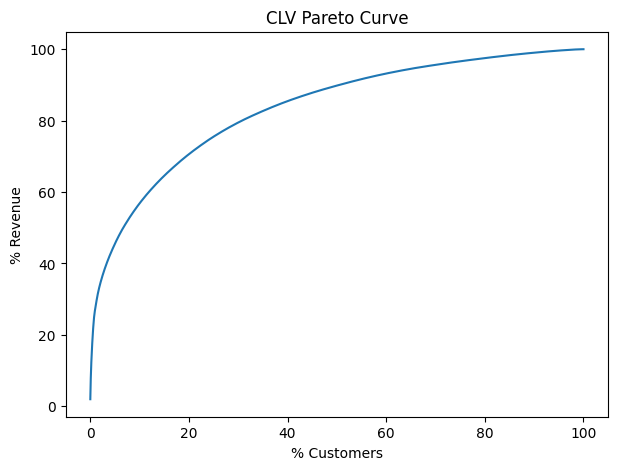

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(df_sorted["cum_customers_%"], df_sorted["cum_revenue_%"])
plt.xlabel("% Customers")
plt.ylabel("% Revenue")
plt.title("CLV Pareto Curve")
plt.show()

In [10]:
recommendations = {
    "VIP": "Provide premium support, loyalty rewards, early access offers",
    "High": "Upsell & cross-sell campaigns, personalized marketing",
    "Medium": "Engagement campaigns to increase frequency",
    "Low": "Cost-efficient marketing or automated retention"
}

segment_actions = pd.DataFrame(
    recommendations.items(),
    columns=["CLV_Segment", "Recommended_Action"]
)

segment_actions

,CLV_Segment,Recommended_Action
0,VIP,"Provide premium support, loyalty rewards, earl..."
1,High,"Upsell & cross-sell campaigns, personalized ma..."
2,Medium,Engagement campaigns to increase frequency
3,Low,Cost-efficient marketing or automated retention


In [11]:
segment_summary.to_csv(f"{project_root}/Data/segment_business_summary.csv")
segment_profit.to_csv(f"{project_root}/Data/segment_profitability.csv")

print("Business impact tables saved")

Business impact tables saved
